# Validación de `loader.py`

Este notebook verifica que el pipeline de carga implementado en `loader.py` produce un dataset base correcto y completo.

**Prerrequisito**: haber ejecutado `01_exploration.ipynb` al menos una vez para generar los artefactos CCS en `data/interim/`.

## 1. Setup del entorno

El paquete `triaje_ia` está instalado en modo editable via `uv sync`. Se importan las funciones principales del loader y las rutas universales desde `triaje_ia.config`.

In [1]:
from triaje_ia.config import DATA_RAW, DATA_INTERIM, DATA_PROCESSED, MODELS_DIR, FIGURES_DIR
from triaje_ia.data.loader import cargar_dataset_base
import pandas as pd

## 2. Carga del dataset base

Se ejecuta el pipeline completo: carga de tablas raw, cálculo de edad, agregación de medicación, mapeo ICD→CCS y construcción del label de disposition. Con `forzar=True` se regenera el caché aunque ya exista, garantizando que estamos viendo el resultado del código actual y no de una ejecución anterior.

In [3]:
df = cargar_dataset_base(forzar=True)
# forzar=True la primera vez para que genere el caché, las siguientes veces se puede quitar o dejarlo en False

2026-03-07 17:07:52.933 | INFO     | triaje_ia.data.loader:cargar_tablas_raw:109 - EDSTAYS: 425,087 filas | 9 columnas
2026-03-07 17:07:53.464 | INFO     | triaje_ia.data.loader:cargar_tablas_raw:109 - TRIAGE: 425,087 filas | 11 columnas
2026-03-07 17:07:57.676 | INFO     | triaje_ia.data.loader:cargar_tablas_raw:109 - MEDRECON: 2,987,342 filas | 9 columnas
2026-03-07 17:07:57.814 | INFO     | triaje_ia.data.loader:cargar_tablas_raw:125 - PATIENTS (MIMIC-IV core): 364,627 pacientes
2026-03-07 17:07:58.354 | INFO     | triaje_ia.data.loader:cargar_tablas_raw:137 - DIAGNOSIS: 899,050 filas
2026-03-07 17:07:58.355 | INFO     | triaje_ia.data.loader:construir_dataset_base:334 - Construyendo dataset base...
2026-03-07 17:07:58.555 | INFO     | triaje_ia.data.loader:construir_dataset_base:344 - edstays INNER triage: 425,087 filas
2026-03-07 17:07:58.950 | INFO     | triaje_ia.data.loader:_calcular_edad:181 - Edad: mediana=53 | rango=[18, 103] | nulos=76
2026-03-07 17:09:46.831 | INFO     | t

### 2.1 Dimensiones y tipos de columna

Se verifica que el DataFrame tiene las dimensiones esperadas y que los tipos de dato son los correctos.

In [4]:
print(df.shape)        # (filas, columnas) — 
df.dtypes              # tipos de cada columna

(425087, 53)


subject_id                         int64
hadm_id                          float64
stay_id                            int64
intime                    datetime64[ns]
outtime                           object
gender                            object
race                              object
arrival_transport                 object
disposition                       object
temperature                      float64
heartrate                        float64
resprate                         float64
o2sat                            float64
sbp                              float64
dbp                              float64
pain                              object
acuity                           float64
chiefcomplaint                    object
age                                Int64
n_medicamentos                     int16
medicacion_raw                    object
med_estatina                        int8
med_antiagregante                   int8
med_anticoagulante                  int8
med_betabloquean

### 2.2 Vista de las primeras filas

Inspección visual del dataset transpuesto para verificar que las columnas tienen valores coherentes. 

In [5]:
df.head(3).T           

,0,1,2
subject_id,10000032,10000032,10000032
hadm_id,22595853.0,22841357.0,25742920.0
stay_id,33258284,38112554,35968195
intime,2180-05-06 19:17:00,2180-06-26 15:54:00,2180-08-05 20:58:00
outtime,2180-05-06 23:30:00,2180-06-26 21:31:00,2180-08-06 01:44:00
gender,F,F,F
race,WHITE,WHITE,WHITE
arrival_transport,AMBULANCE,AMBULANCE,AMBULANCE
disposition,ADMITTED,ADMITTED,ADMITTED
temperature,98.4,98.9,99.4


### 2.3 Análisis de valores nulos

Se cuantifica el porcentaje de nulos por columna para identificar qué variables tienen datos faltantes.

In [6]:
nulos = df.isna().sum()
nulos_pct = (nulos / len(df) * 100).round(1)

resumen_nulos = pd.DataFrame({
    "n_nulos": nulos,
    "pct": nulos_pct
}).query("n_nulos > 0").sort_values("pct", ascending=False)

resumen_nulos

,n_nulos,pct
hadm_id,222071,52.2
temperature,23415,5.5
resprate,20353,4.8
o2sat,20596,4.8
dbp,19091,4.5
sbp,18291,4.3
heartrate,17090,4.0
pain,12933,3.0
acuity,6987,1.6
ccs_category,1108,0.3


### 2.4 Distribución de los targets

Se verifica la distribución de las dos variables objetivo:
- **`acuity`** (1–5): se espera predominio del nivel 3 (~53%).
- **`label_disposition`** (0/1): se espera ~35–40% de ingresos.

In [7]:
print("=== ACUITY ===")
print(df["acuity"].value_counts(dropna=False).sort_index())

print("\n=== DISPOSITION ===")
print(df["label_disposition"].value_counts(dropna=False))

=== ACUITY ===
acuity
1.0     24019
2.0    139411
3.0    225066
4.0     28504
5.0      1100
NaN      6987
Name: count, dtype: int64

=== DISPOSITION ===
label_disposition
0    260052
1    165035
Name: count, dtype: Int64


## 3. Validación de `ccs_category`

La columna `ccs_category` unifica los diagnósticos ICD-9 e ICD-10 en una categoría CCS numérica (1–285). Se verifica que el mapeo se ha ejecutado correctamente y se consultan los nombres de las categorías más frecuentes usando los parquets CCS generados en `01_exploration.ipynb`.

In [8]:
from triaje_ia.data.loader import cargar_mappings_ccs

ccs_icd9, ccs_icd10 = cargar_mappings_ccs()

# El nombre canónico está en ICD-10 (descripciones más completas)
nombres_ccs = (
    ccs_icd10[["CCS CATEGORY", "CCS CATEGORY DESCRIPTION"]]
    .drop_duplicates("CCS CATEGORY")
    .rename(columns={"CCS CATEGORY": "ccs_category", 
                     "CCS CATEGORY DESCRIPTION": "ccs_nombre"})
)
nombres_ccs["ccs_category"] = pd.to_numeric(nombres_ccs["ccs_category"], errors="coerce")

# Ver el top 10 con nombre
top10 = (
    df["ccs_category"]
    .value_counts()
    .head(10)
    .reset_index()
    .merge(nombres_ccs, on="ccs_category", how="left")
)
print(top10.to_string(index=False))

 ccs_category  count                                                      ccs_nombre
          251  32056                                                  Abdominal pain
          102  24199                                          Nonspecific chest pain
          205  14809 Spondylosis; intervertebral disc disorders; other back problems
          259  11445                                    Residual codes; unclassified
          133  11212                                 Other lower respiratory disease
           84  10614                                    Headache; including migraine
          211  10342                                 Other connective tissue disease
          660  10187                                       Alcohol-related disorders
          244   9386            Other injuries and conditions due to external causes
          197   9191                         Skin and subcutaneous tissue infections


## 4. Validación de flags de medicación previa

Se verifica que los 30 flags binarios `med_*` se han generado correctamente y se analiza su prevalencia en el dataset. Cada flag indica si el paciente tomaba fármacos de esa clase antes de llegar a urgencias, según el registro de `medrecon`.

In [9]:
med_cols = [c for c in df.columns if c.startswith("med_")]

(df[med_cols]
    .sum()
    .sort_values(ascending=False)
    .rename("n_pacientes")
    .to_frame()
    .assign(pct=lambda x: (x["n_pacientes"] / len(df) * 100).round(1))
)

,n_pacientes,pct
med_antiacido,106337,25.0
med_estatina,100949,23.7
med_opioide,100325,23.6
med_antidepresivo,98238,23.1
med_antiagregante,90657,21.3
med_betabloqueante,90548,21.3
med_ieca_ara2,80566,19.0
med_diuretico,78303,18.4
med_anticonvulsivo,65338,15.4
med_broncodilatador,61160,14.4


### 4.1 Análisis de `n_medicamentos`

Se analiza la distribución del número de medicamentos previos por visita para detectar posibles anomalías. En particular, se investigan los casos con un número extremadamente alto de medicamentos

In [10]:
print(df["n_medicamentos"].describe())
print(f"\nSin medicación registrada: {df['n_medicamentos'].isna().sum():,}")
# Los NaN aquí son stays que directamente no aparecen en medrecon (LEFT JOIN)

count    425087.000000
mean          6.004350
std           6.705543
min           0.000000
25%           0.000000
50%           4.000000
75%          10.000000
max          67.000000
Name: n_medicamentos, dtype: float64

Sin medicación registrada: 0


In [11]:
print(df["n_medicamentos"].max())
df.nlargest(5, "n_medicamentos")[["stay_id", "age", "n_medicamentos"]].T

67


,365354,23115,23130,23113,365353
stay_id,34395897,30808521,36988087,30620517,37825252
age,61,83,83,82,61
n_medicamentos,67,63,63,57,57


In [12]:
df[df["n_medicamentos"] == 67].T

,365354
subject_id,18592426
hadm_id,29832710.0
stay_id,34395897
intime,2186-04-22 09:49:00
outtime,2186-04-22 17:07:00
gender,M
race,WHITE
arrival_transport,WALK IN
disposition,ADMITTED
temperature,98.6


In [13]:
df.nlargest(10, "n_medicamentos")[["stay_id", "subject_id", "age", "gender", "acuity", "n_medicamentos", "medicacion_raw"]].T

,365354,23115,23130,23113,365353,23131,126772,233830,363988,363995
stay_id,34395897,30808521,36988087,30620517,37825252,39347674,32963238,35867442,39075599,33349490
subject_id,18592426,10561909,10561909,10561909,18592426,10561909,13009233,15497609,18561128,18561128
age,61,83,83,82,61,82,61,69,48,47
gender,M,F,F,F,M,F,F,F,F,F
acuity,2.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0,2.0,3.0
n_medicamentos,67,63,63,57,57,56,55,55,54,54
medicacion_raw,"accu-chek aviva, androgel, astelin, calcitriol...","acetaminophen, albuterol sulfate, albuterol su...","acetaminophen, albuterol sulfate, albuterol su...","acetaminophen, acetic acid, albuterol sulfate,...","accu-chek aviva, amlodipine, androgel, aspirin...","acetaminophen, acetic acid, albuterol sulfate,...","acetaminophen [acetaminophen extra strength], ...","acetaminophen, acetaminophen-codeine, acyclovi...","acetaminophen, albuterol sulfate, albuterol su...","acetaminophen, albuterol sulfate, albuterol su..."


In [14]:
caso = df[df["n_medicamentos"] == 67].iloc[0]
print(caso["medicacion_raw"])

accu-chek aviva, androgel, astelin, calcitriol, calcium carbonate-vitamin d3 [calcium 600 with vitamin d3], chlorhexidine gluconate, ciclopirox, clarinex, clindamycin phosphate, coenzyme q10, creon 20, crestor, dextroamphetamine-amphetamine [amphetamine salt combo], digoxin, duloxetine, emtriva, erythromycin, folgard rx, gammagard s/d, glucophage, humalog pen, humulin n pen, hydrochlorothiazide, mupirocin, nasonex, neupogen, niaspan, nystatin, nystatin-triamcinolone, omeprazole, prevident, prezista, procrit, propecia, provigil, singulair, somatropin [serostim], synthroid, terbinafine hcl, tivicay, valtrex, viagra, viramune xr, ziagen, gabapentin, potassium chloride, selzentry, vasotec, *domperidone, fulyzaq, levocarnitine, revatio, fludrocortisone, lovaza, restasis, k-phos no 2, namenda, norvir, oxazepam, amlodipine, magnesium oxide, qvar, vitamin d3, bayer aspirin, vitamin e, atenolol, glimepiride


### 4.2 Distribución de edad

Verificación de que el cálculo de edad a partir de `anchor_age` y `anchor_year` (MIMIC-IV core) produce una distribución fisiológicamente plausible. 

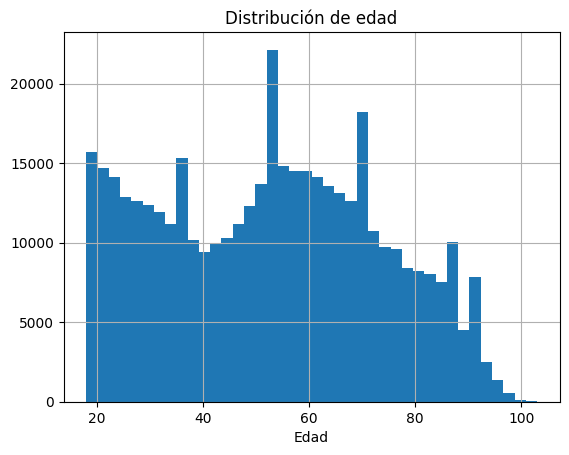

count     425011.0
mean     52.864493
std      20.619906
min           18.0
25%           35.0
50%           53.0
75%           69.0
max          103.0
Name: age, dtype: Float64


In [9]:
import matplotlib.pyplot as plt

df["age"].hist(bins=40)
plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.show()

print(df["age"].describe())

## 5. Resumen visual del dataset base

Panel de 7 gráficos que ofrece una radiografía completa del dataset en el minuto 0: distribución de los targets (acuity y disposition), demografía (edad), constantes vitales, valores nulos y perfil de medicación previa. Esta figura resume de forma compacta todo lo que el modelo tiene disponible en el momento del triaje.

C:\Users\CARLOS\AppData\Local\Temp\ipykernel_35856\837035731.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(data_vitales, labels=vitales, patch_artist=True,
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_35856\837035731.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


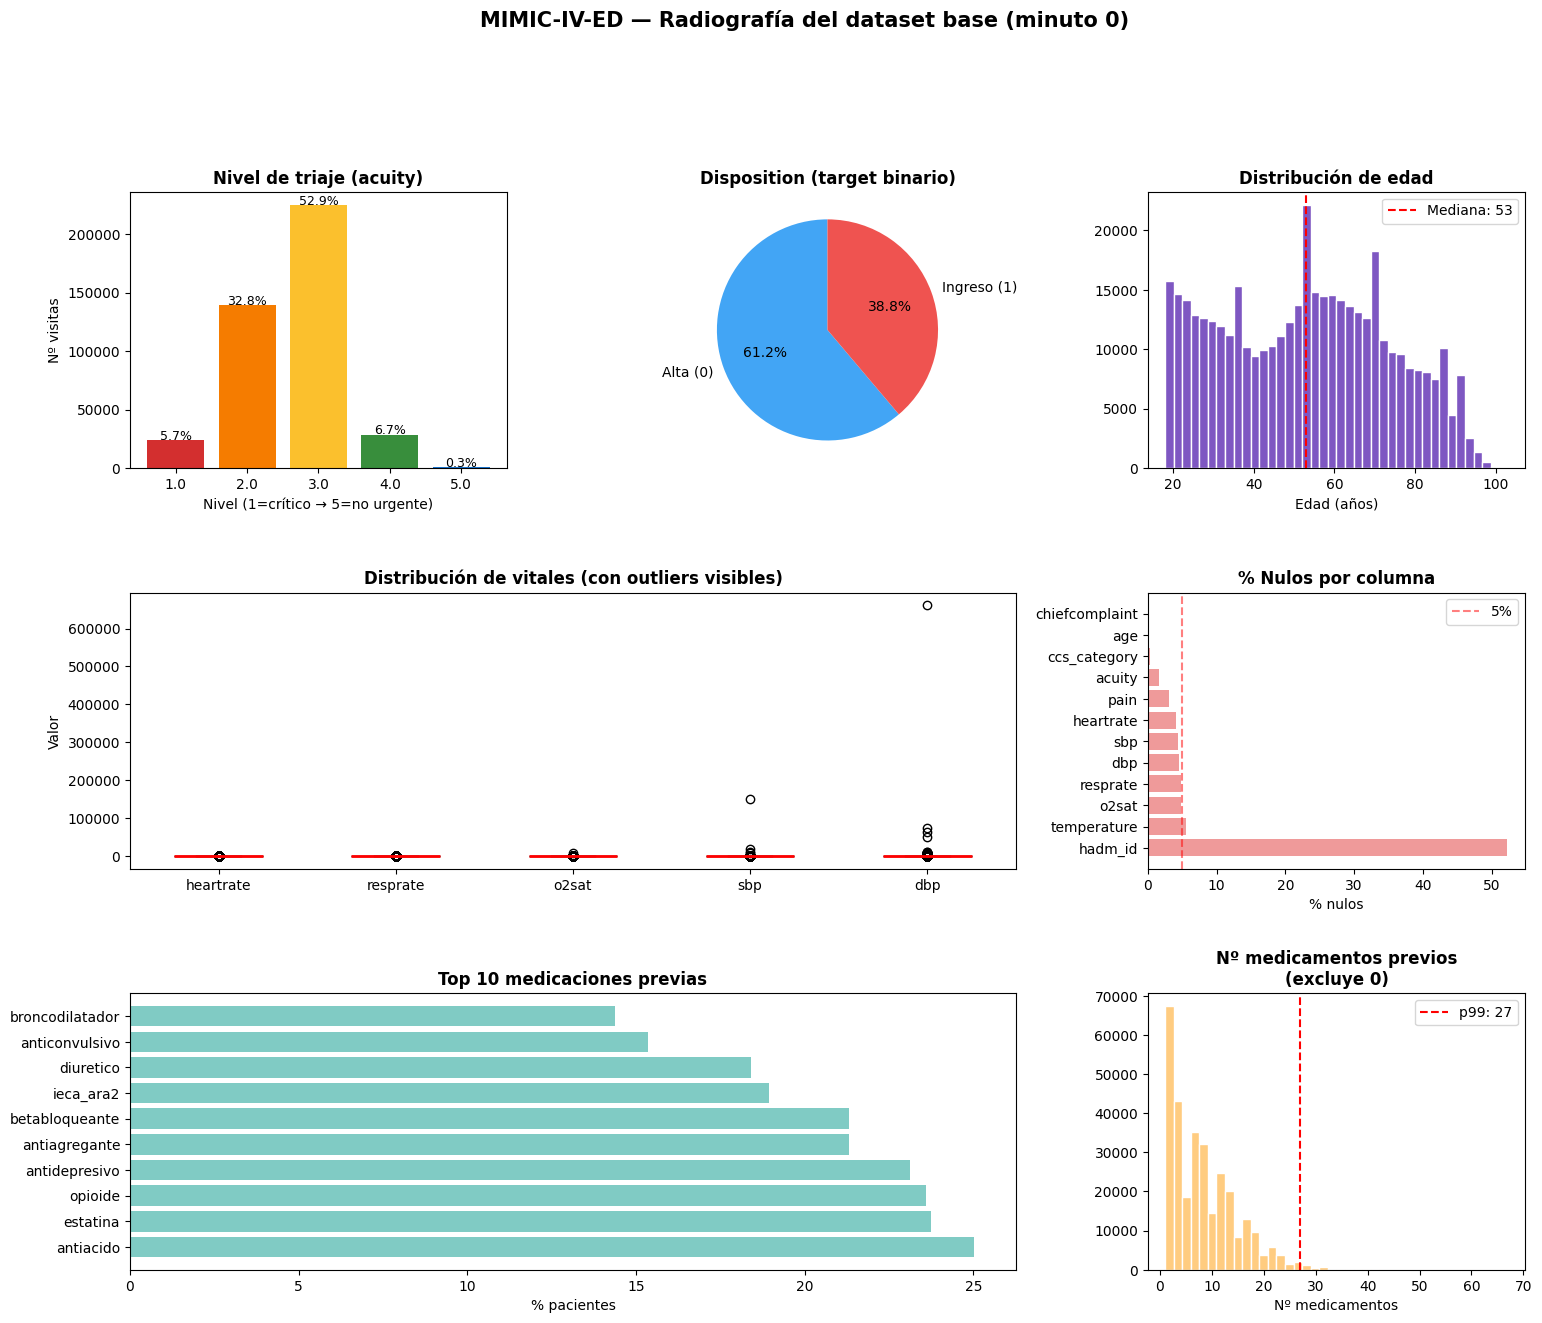

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 14))
fig.suptitle("MIMIC-IV-ED — Radiografía del dataset base (minuto 0)", 
             fontsize=15, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Distribución de acuity ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
acuity_counts = df["acuity"].value_counts().sort_index()
bars = ax1.bar(acuity_counts.index.astype(str), acuity_counts.values,
               color=["#d32f2f","#f57c00","#fbc02d","#388e3c","#1976d2"])
ax1.set_title("Nivel de triaje (acuity)", fontweight="bold")
ax1.set_xlabel("Nivel (1=crítico → 5=no urgente)")
ax1.set_ylabel("Nº visitas")
for bar, val in zip(bars, acuity_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f"{val/len(df)*100:.1f}%", ha="center", fontsize=9)

# ── 2. Label disposition ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
disp_counts = df["label_disposition"].value_counts().sort_index()
ax2.pie(disp_counts.values,
        labels=["Alta (0)", "Ingreso (1)"],
        autopct="%1.1f%%",
        colors=["#42a5f5", "#ef5350"],
        startangle=90)
ax2.set_title("Disposition (target binario)", fontweight="bold")

# ── 3. Distribución de edad ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df["age"].dropna(), bins=40, color="#7e57c2", edgecolor="white")
ax3.axvline(df["age"].median(), color="red", linestyle="--", 
            label=f"Mediana: {df['age'].median():.0f}")
ax3.set_title("Distribución de edad", fontweight="bold")
ax3.set_xlabel("Edad (años)")
ax3.legend()

# ── 4. Vitales — boxplots ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
vitales = ["heartrate", "resprate", "o2sat", "sbp", "dbp"]
data_vitales = [df[v].dropna().values for v in vitales]
bp = ax4.boxplot(data_vitales, labels=vitales, patch_artist=True,
                 medianprops=dict(color="red", linewidth=2))
colors = ["#4fc3f7","#81c784","#ffb74d","#e57373","#ba68c8"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax4.set_title("Distribución de vitales (con outliers visibles)", fontweight="bold")
ax4.set_ylabel("Valor")

# ── 5. Nulos por columna ───────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
nulos_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
nulos_pct = nulos_pct[nulos_pct > 0]
ax5.barh(nulos_pct.index, nulos_pct.values, color="#ef9a9a")
ax5.set_title("% Nulos por columna", fontweight="bold")
ax5.set_xlabel("% nulos")
ax5.axvline(5, color="red", linestyle="--", alpha=0.5, label="5%")
ax5.legend()

# ── 6. Top 10 flags farmacológicos ────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :2])
med_cols = [c for c in df.columns if c.startswith("med_")]
med_pct = (df[med_cols].sum() / len(df) * 100).sort_values(ascending=False).head(10)
ax6.barh(med_pct.index.str.replace("med_", ""), med_pct.values, color="#80cbc4")
ax6.set_title("Top 10 medicaciones previas", fontweight="bold")
ax6.set_xlabel("% pacientes")

# ── 7. n_medicamentos ─────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
ax7.hist(df[df["n_medicamentos"] > 0]["n_medicamentos"], 
         bins=40, color="#ffcc80", edgecolor="white")
ax7.axvline(df["n_medicamentos"].quantile(0.99), color="red", 
            linestyle="--", label=f"p99: {df['n_medicamentos'].quantile(0.99):.0f}")
ax7.set_title("Nº medicamentos previos\n(excluye 0)", fontweight="bold")
ax7.set_xlabel("Nº medicamentos")
ax7.legend()

plt.tight_layout()
plt.show()

## 6. Caso de ejemplo: paciente típico de urgencias

Para verificar que el dataset es internamente coherente, se extrae un paciente representativo (acuity 3, entre 50 y 60 años, 5–10 medicamentos previos, ingresado) y se imprime su perfil completo. Esto permite comprobar visualmente que todas las columnas tienen valores con sentido clínico para un mismo paciente.

In [17]:
ejemplo = df[
    (df["acuity"] == 3) &
    (df["age"].between(50, 60)) &
    (df["n_medicamentos"].between(5, 10)) &
    (df["label_disposition"] == 1)
].iloc[0]

cols_fijas = [
    "stay_id", "subject_id",
    "age", "gender", "race", "arrival_transport",
    "chiefcomplaint", "intime",
    "temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "pain",
    "acuity", "label_disposition", "disposition",
    "n_medicamentos", "medicacion_raw"
]

# Med cols — solo las que tienen 1
med_cols = [c for c in df.columns if c.startswith("med_")]
med_activas = [c for c in med_cols if ejemplo[c] == 1]

print("=" * 45)
print("EJEMPLO: paciente típico de urgencias")
print("=" * 45)

for col in cols_fijas:
    val = ejemplo[col]
    if pd.notna(val) and val != "":
        print(f"  {col:<25} {val}")

print(f"\n  {'Medicaciones activas':<25}")
for col in med_activas:
    print(f"    ✓ {col.replace('med_', '')}")

EJEMPLO: paciente típico de urgencias
  stay_id                   33258284
  subject_id                10000032
  age                       52
  gender                    F
  race                      WHITE
  arrival_transport         AMBULANCE
  chiefcomplaint            Abd pain, Abdominal distention
  intime                    2180-05-06 19:17:00
  temperature               98.4
  heartrate                 70.0
  resprate                  16.0
  o2sat                     97.0
  sbp                       106.0
  dbp                       63.0
  pain                      0
  acuity                    3.0
  label_disposition         1
  disposition               ADMITTED
  n_medicamentos            9
  medicacion_raw            albuterol sulfate, emtricitabine-tenofovir [truvada], ergocalciferol (vitamin d2), furosemide, ipratropium bromide [atrovent hfa], nicotine, peg 3350-electrolytes, raltegravir [isentress], spironolactone [aldactone]

  Medicaciones activas     
    ✓ broncodilat

## 7. Análisis de visitas repetidas por paciente

MIMIC-IV-ED incluye pacientes con múltiples visitas a urgencias a lo largo del tiempo. Se analiza la distribución del número de visitas por paciente para cuantificar este fenómeno, que tiene implicaciones para la validación del modelo: si un mismo paciente aparece en train y test, podría haber data leakage por similitud de perfil clínico.

In [18]:
import pandas as pd

edstays = pd.read_csv(r"C:\Users\CARLOS\triaje-ia-tfg\data\raw\edstays.csv.gz", low_memory=False)

visitas_por_paciente = edstays.groupby("subject_id")["stay_id"].count()

print(visitas_por_paciente.value_counts().sort_index().head(20))
print(f"\nTotal pacientes:         {visitas_por_paciente.shape[0]:,}")
print(f"Con más de 1 visita:     {(visitas_por_paciente > 1).sum():,}")
print(f"Con más de 2 visitas:    {(visitas_por_paciente > 2).sum():,}")
print(f"Mediana visitas:         {visitas_por_paciente.median():.0f}")
print(f"Máximo visitas:          {visitas_por_paciente.max()}")

stay_id
1     135552
2      32672
3      13700
4       7377
5       4375
6       2822
7       2011
8       1416
9       1063
10       802
11       590
12       486
13       415
14       269
15       255
16       210
17       182
18       139
19       120
20       108
Name: count, dtype: int64

Total pacientes:         205,504
Con más de 1 visita:     69,952
Con más de 2 visitas:    37,280
Mediana visitas:         1
Máximo visitas:          321
